# Searchlight per-category specificity: v1 vs v2

Compares two ways of building **per-category** searchlight maps for the 4-class
stimulus-category problem (face / figure / hand / house), from GLMsingle type-D betas.
6 mm sphere, LinearSVC, leave-one-run-out CV.

| | **v1** (`searchlight/`) | **v2** (`searchlight_recall/`) |
|---|---|---|
| Per-category map | one-vs-rest **accuracy** | per-class **recall** from the competitive 4-way model |
| Class balance | 1:3 (imbalanced) | balanced 4-way (`class_weight='balanced'`) |
| Chance | **0.75** (majority-class floor) | **0.25** |
| Problem | accuracy sits on a 0.75 floor, majority-class-driven | reads as "how reliably a sphere identifies category *k* vs the other 3" |

**Why v2:** one-vs-rest accuracy on a 1:3 split is dominated by the "rest" class, so the v1
per-category maps don't cleanly localize a category. Per-class recall from the single
balanced 4-way model does. The overall 4-class map is essentially unchanged between
versions (only `class_weight` added — a near-no-op on the balanced problem); Section 1
confirms this.

**Display principle:** v1 and v2 per-category maps have *different chance levels and value
ranges*, so we never share a raw color scale. Native-unit panels use each version's own
chance-anchored scale; direct comparisons use **chance-corrected** maps (`map − chance`).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from nilearn import image, plotting, datasets

sys.path.insert(0, str(Path('../')))
try:
    from utils.data import load_participant_list
except Exception:
    load_participant_list = None

# --- Auto-detect where the derivatives live (VM mount, else local sync) ---
_DERIV_CANDIDATES = [
    Path('/mnt/data/learning-habits/bids_dataset/derivatives'),                          # uzh.vm
    Path.home() / 'phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives',   # local Mac sync
]
DERIVATIVES_DIR = next((p for p in _DERIV_CANDIDATES if p.exists()), _DERIV_CANDIDATES[0])
print(f'DERIVATIVES_DIR = {DERIVATIVES_DIR}')
# --------------------------------------------------------------------------

SL_V1 = DERIVATIVES_DIR / 'searchlight'          # one-vs-rest accuracy, chance 0.75
SL_V2 = DERIVATIVES_DIR / 'searchlight_recall'   # per-class recall,      chance 0.25
VC_MASK_PATH = DERIVATIVES_DIR / 'decoding' / 'visual_cortex_mask.nii.gz'
FUSIFORM_MASK_PATH = DERIVATIVES_DIR.parent.parent / 'masks' / 'MNI152NLin2009cAsym' / 'fusiform_mask_MNI152NLin2009cAsym.nii'
PARTICIPANTS_FILE = DERIVATIVES_DIR.parent.parent / 'participants_mvpa.tsv'

STIM_CATS = ['face', 'figure', 'hand', 'house']
CHANCE_OVERALL = 0.25       # 4-class map (both versions)
CHANCE_V1 = 0.75            # v1 per-category: one-vs-rest accuracy floor
CHANCE_V2 = 0.25            # v2 per-category: per-class recall under 4-way null
ALPHA_FDR = 0.05

# v1/v2 per-category filename builders (they differ: v2 carries a `recall_` infix)
def v1_cat_path(sub, cat):
    return SL_V1 / f'sub-{sub}' / f'sub-{sub}_searchlight_stim_cat_{cat}.nii.gz'
def v2_cat_path(sub, cat):
    return SL_V2 / f'sub-{sub}' / f'sub-{sub}_searchlight_stim_cat_recall_{cat}.nii.gz'
def overall_path(root, sub):
    return root / f'sub-{sub}' / f'sub-{sub}_searchlight_stim_cat.nii.gz'

# Subject list: prefer the canonical TSV, else intersect what both versions produced
if load_participant_list is not None and PARTICIPANTS_FILE.exists():
    subjects = load_participant_list(PARTICIPANTS_FILE.parent, file_name=PARTICIPANTS_FILE.name)
else:
    v1_subs = {p.name[4:] for p in SL_V1.glob('sub-*') if p.is_dir()}
    v2_subs = {p.name[4:] for p in SL_V2.glob('sub-*') if p.is_dir()}
    subjects = sorted(v1_subs & v2_subs)
print(f'Candidate subjects: {len(subjects)}')

DERIVATIVES_DIR = /mnt/data/learning-habits/bids_dataset/derivatives
Candidate subjects: 59


## 0. Completeness & group mask

Keep only subjects that have **both** versions complete (overall map + all 4 per-category
maps in each). Build a single group brain mask (MNI152 resampled to the map grid) used for
all voxelwise stats. `concat_imgs` requires a common affine/shape — we guard the load loop
and report any offenders rather than letting a cell crash.

In [2]:
def complete(sub):
    ok = overall_path(SL_V1, sub).exists() and overall_path(SL_V2, sub).exists()
    ok &= all(v1_cat_path(sub, c).exists() for c in STIM_CATS)
    ok &= all(v2_cat_path(sub, c).exists() for c in STIM_CATS)
    return ok

subs = [s for s in subjects if complete(s)]
dropped = [s for s in subjects if s not in subs]
print(f'Subjects with BOTH versions complete: {len(subs)}')
if dropped:
    print(f'Dropped (incomplete in v1 and/or v2): {dropped}')

def load_4d(paths, ref_affine=None, ref_shape=None):
    """Load a list of NIfTI paths into a 4D image, guarding grid consistency."""
    imgs, bad = [], []
    for p in paths:
        img = nib.load(p)
        if ref_shape is None:
            ref_affine, ref_shape = img.affine, img.shape[:3]
        if img.shape[:3] != ref_shape or not np.allclose(img.affine, ref_affine, atol=1e-3):
            bad.append(Path(p).parent.name)
            continue
        imgs.append(img)
    if bad:
        print(f'  WARNING: {len(bad)} maps off-grid, skipped: {bad}')
    return image.concat_imgs(imgs), ref_affine, ref_shape

# Overall 4-class maps (v2) define the reference grid; assert v1 shares it per subject
ov2, aff, shp = load_4d([overall_path(SL_V2, s) for s in subs])
ov1, _, _     = load_4d([overall_path(SL_V1, s) for s in subs], aff, shp)
assert not np.isnan(ov2.get_fdata()).all(), 'v2 overall maps all-NaN?'
print(f'Overall 4D shapes  v1={ov1.shape}  v2={ov2.shape}')

# Group brain mask
mni_mask = datasets.load_mni152_brain_mask()
group_mask = image.resample_to_img(mni_mask, ov2, interpolation='nearest')
mask_data = group_mask.get_fdata().astype(bool)
print(f'Group brain mask: {mask_data.sum()} voxels')

def load_roi_mask(mask_path, ref_img, brain_mask):
    roi = image.resample_to_img(str(mask_path), ref_img, interpolation='nearest')
    return roi.get_fdata().astype(bool) & brain_mask

Subjects with BOTH versions complete: 59


Overall 4D shapes  v1=(53, 65, 48, 59)  v2=(53, 65, 48, 59)
Group brain mask: 59793 voxels


## 1. Overall 4-class map: v1 vs v2 (sanity)

The overall 4-class searchlight is the *same* analysis in both versions, differing only by
`class_weight='balanced'` — a near-no-op on the balanced 4-way problem. Per-subject
whole-brain mean accuracy should fall on the identity line. This validates the decision to
let v2 re-emit its own overall map rather than reuse v1's.

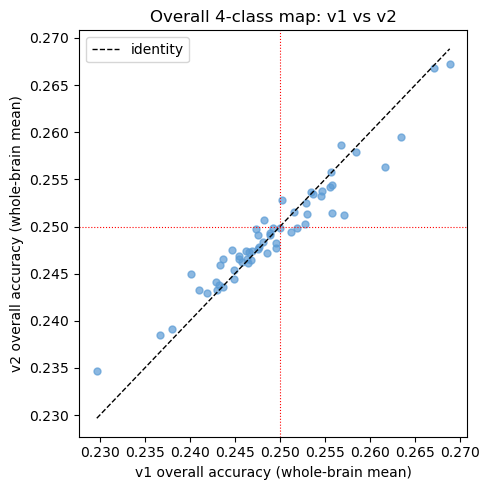

v2 - v1 overall whole-brain mean: +0.0001 ± 0.0020 (max |diff| = 0.0058)


In [3]:
ov1_mean = ov1.get_fdata()[mask_data, :].mean(axis=0)   # per-subject whole-brain mean
ov2_mean = ov2.get_fdata()[mask_data, :].mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
lo = min(ov1_mean.min(), ov2_mean.min()); hi = max(ov1_mean.max(), ov2_mean.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='identity')
ax.scatter(ov1_mean, ov2_mean, s=25, alpha=0.7, color='#5B9BD5')
ax.axvline(CHANCE_OVERALL, color='red', ls=':', lw=0.8)
ax.axhline(CHANCE_OVERALL, color='red', ls=':', lw=0.8)
ax.set_xlabel('v1 overall accuracy (whole-brain mean)')
ax.set_ylabel('v2 overall accuracy (whole-brain mean)')
ax.set_title('Overall 4-class map: v1 vs v2')
ax.legend()
plt.tight_layout(); plt.show()

d = ov2_mean - ov1_mean
print(f'v2 - v1 overall whole-brain mean: {d.mean():+.4f} ± {d.std():.4f} '
      f'(max |diff| = {np.abs(d).max():.4f})')

## 2. Per-category group-mean maps, side by side (native units)

Each version on its **own** chance-anchored scale (v1: 0.75–0.90 accuracy; v2: 0.25–0.60
recall). Not directly comparable in absolute value — this panel shows each in its native
units; Section 3 puts them on a shared, comparable scale.

/home/ubuntu/miniforge3/envs/neuroim/lib/python3.10/site-packages/nilearn/plotting/displays/_slicers.py:308: UserWarning: empty mask
  ims = self._map_show(img, type="imshow", threshold=threshold, **kwargs)


/tmp/ipykernel_57911/2033297268.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


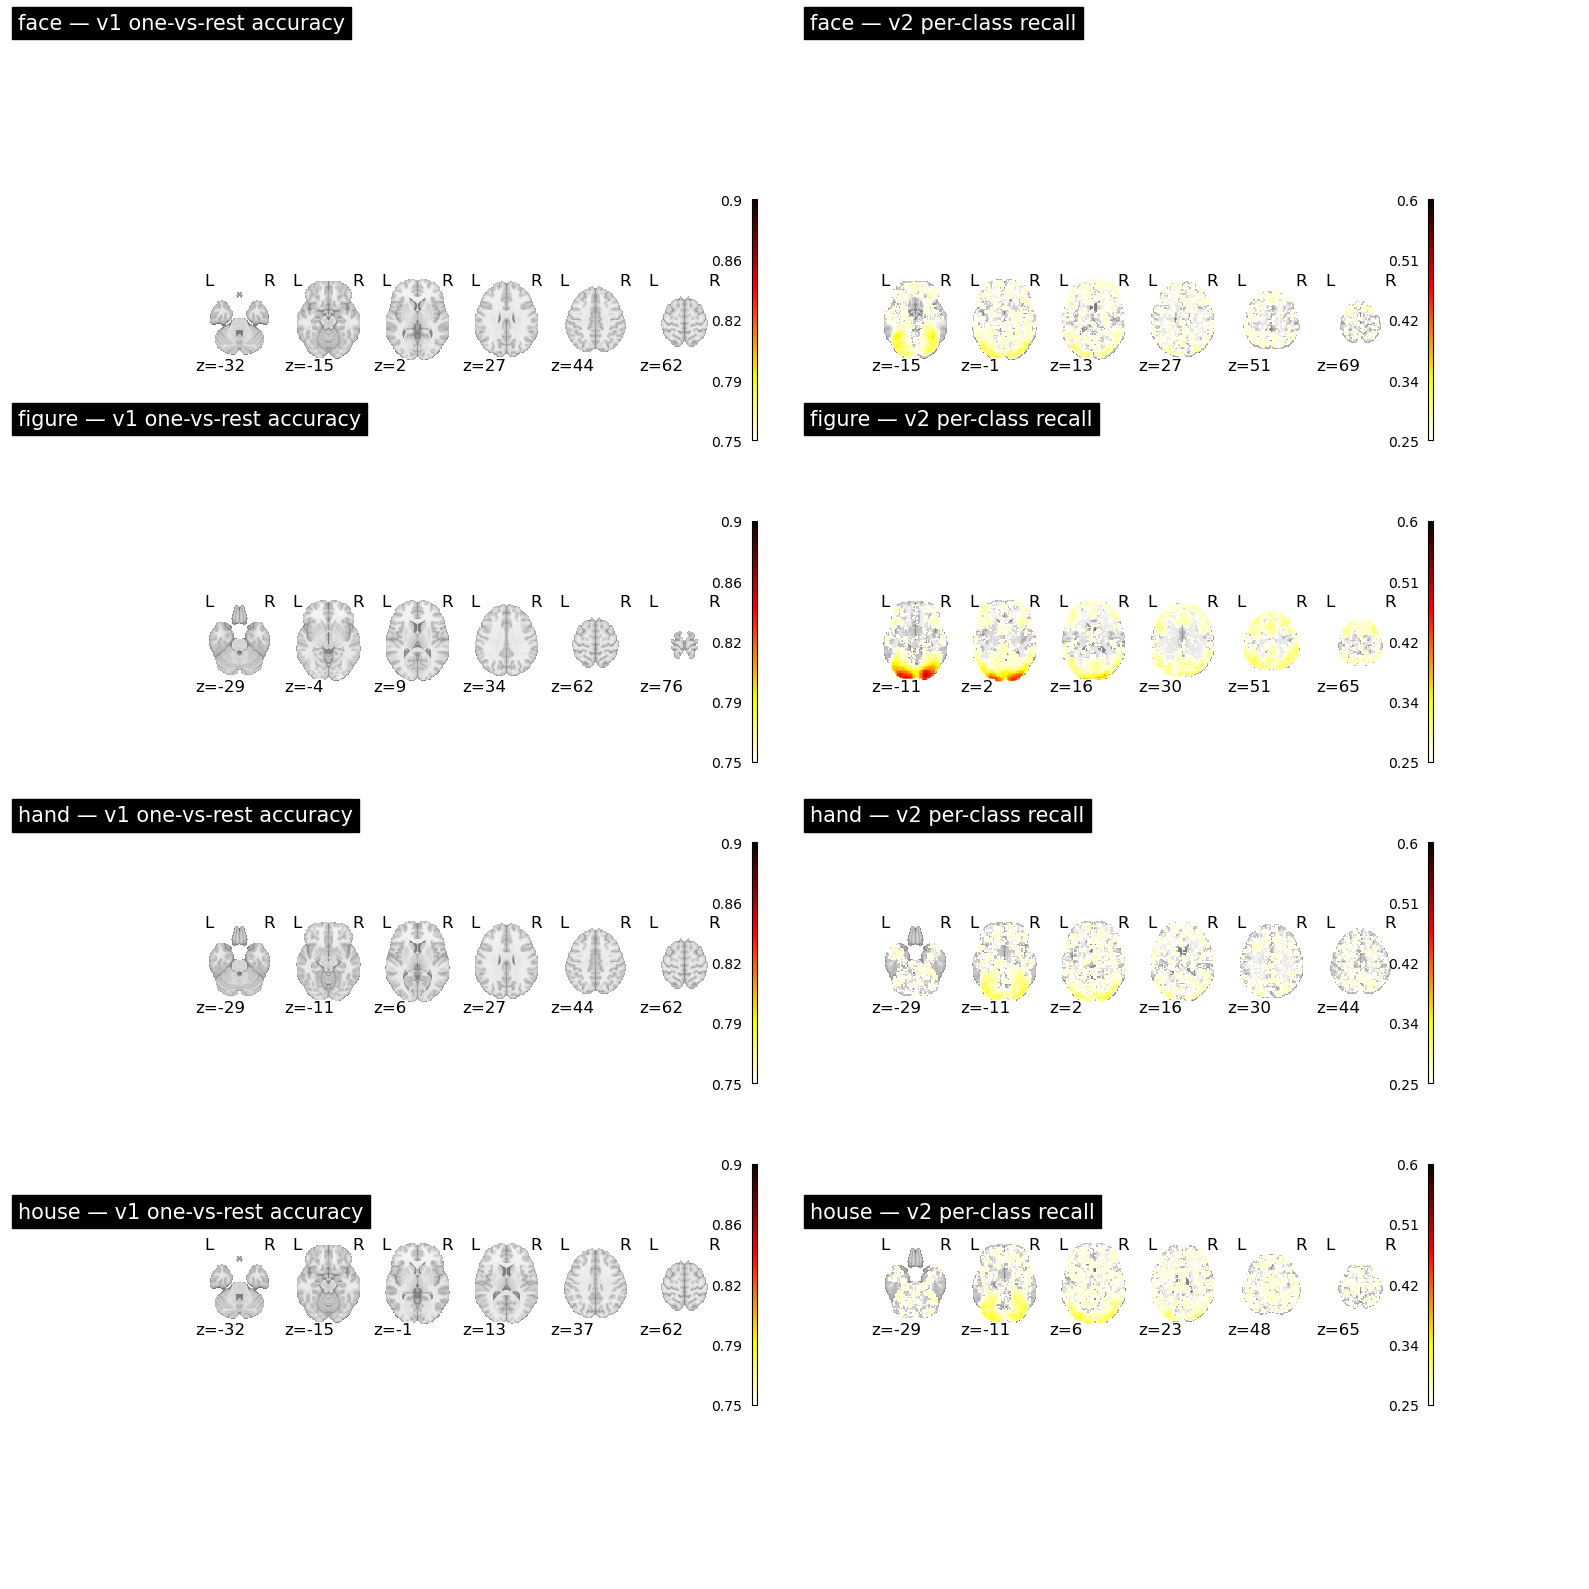

In [4]:
# Load all per-category maps into 4D (subjects along 4th dim), both versions
cat_v1, cat_v2 = {}, {}
for c in STIM_CATS:
    cat_v1[c], _, _ = load_4d([v1_cat_path(s, c) for s in subs], aff, shp)
    cat_v2[c], _, _ = load_4d([v2_cat_path(s, c) for s in subs], aff, shp)
mean_v1 = {c: image.mean_img(cat_v1[c]) for c in STIM_CATS}
mean_v2 = {c: image.mean_img(cat_v2[c]) for c in STIM_CATS}

fig, axes = plt.subplots(len(STIM_CATS), 2, figsize=(16, 4 * len(STIM_CATS)))
for row, c in enumerate(STIM_CATS):
    plotting.plot_stat_map(mean_v1[c], threshold=CHANCE_V1, colorbar=True,
        title=f'{c} — v1 one-vs-rest accuracy', display_mode='z', cut_coords=6,
        axes=axes[row, 0], cmap='hot_r', vmin=CHANCE_V1, vmax=0.90)
    plotting.plot_stat_map(mean_v2[c], threshold=CHANCE_V2, colorbar=True,
        title=f'{c} — v2 per-class recall', display_mode='z', cut_coords=6,
        axes=axes[row, 1], cmap='hot_r', vmin=CHANCE_V2, vmax=0.60)
plt.tight_layout(); plt.show()

## 3. Chance-corrected group means (shared scale) — headline comparison

Subtract each version's chance level (v1: 0.75, v2: 0.25) so both center on 0 and can share
one diverging color scale. This is the fair side-by-side: it shows *where each map rises
above its own chance*, so spatial focality is directly comparable. Expect v2 recall to be
more focal in category-selective cortex and less diffuse than v1's majority-driven
accuracy.

shared |Δ| cap (99th pct): 0.517


/tmp/ipykernel_57911/720818527.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


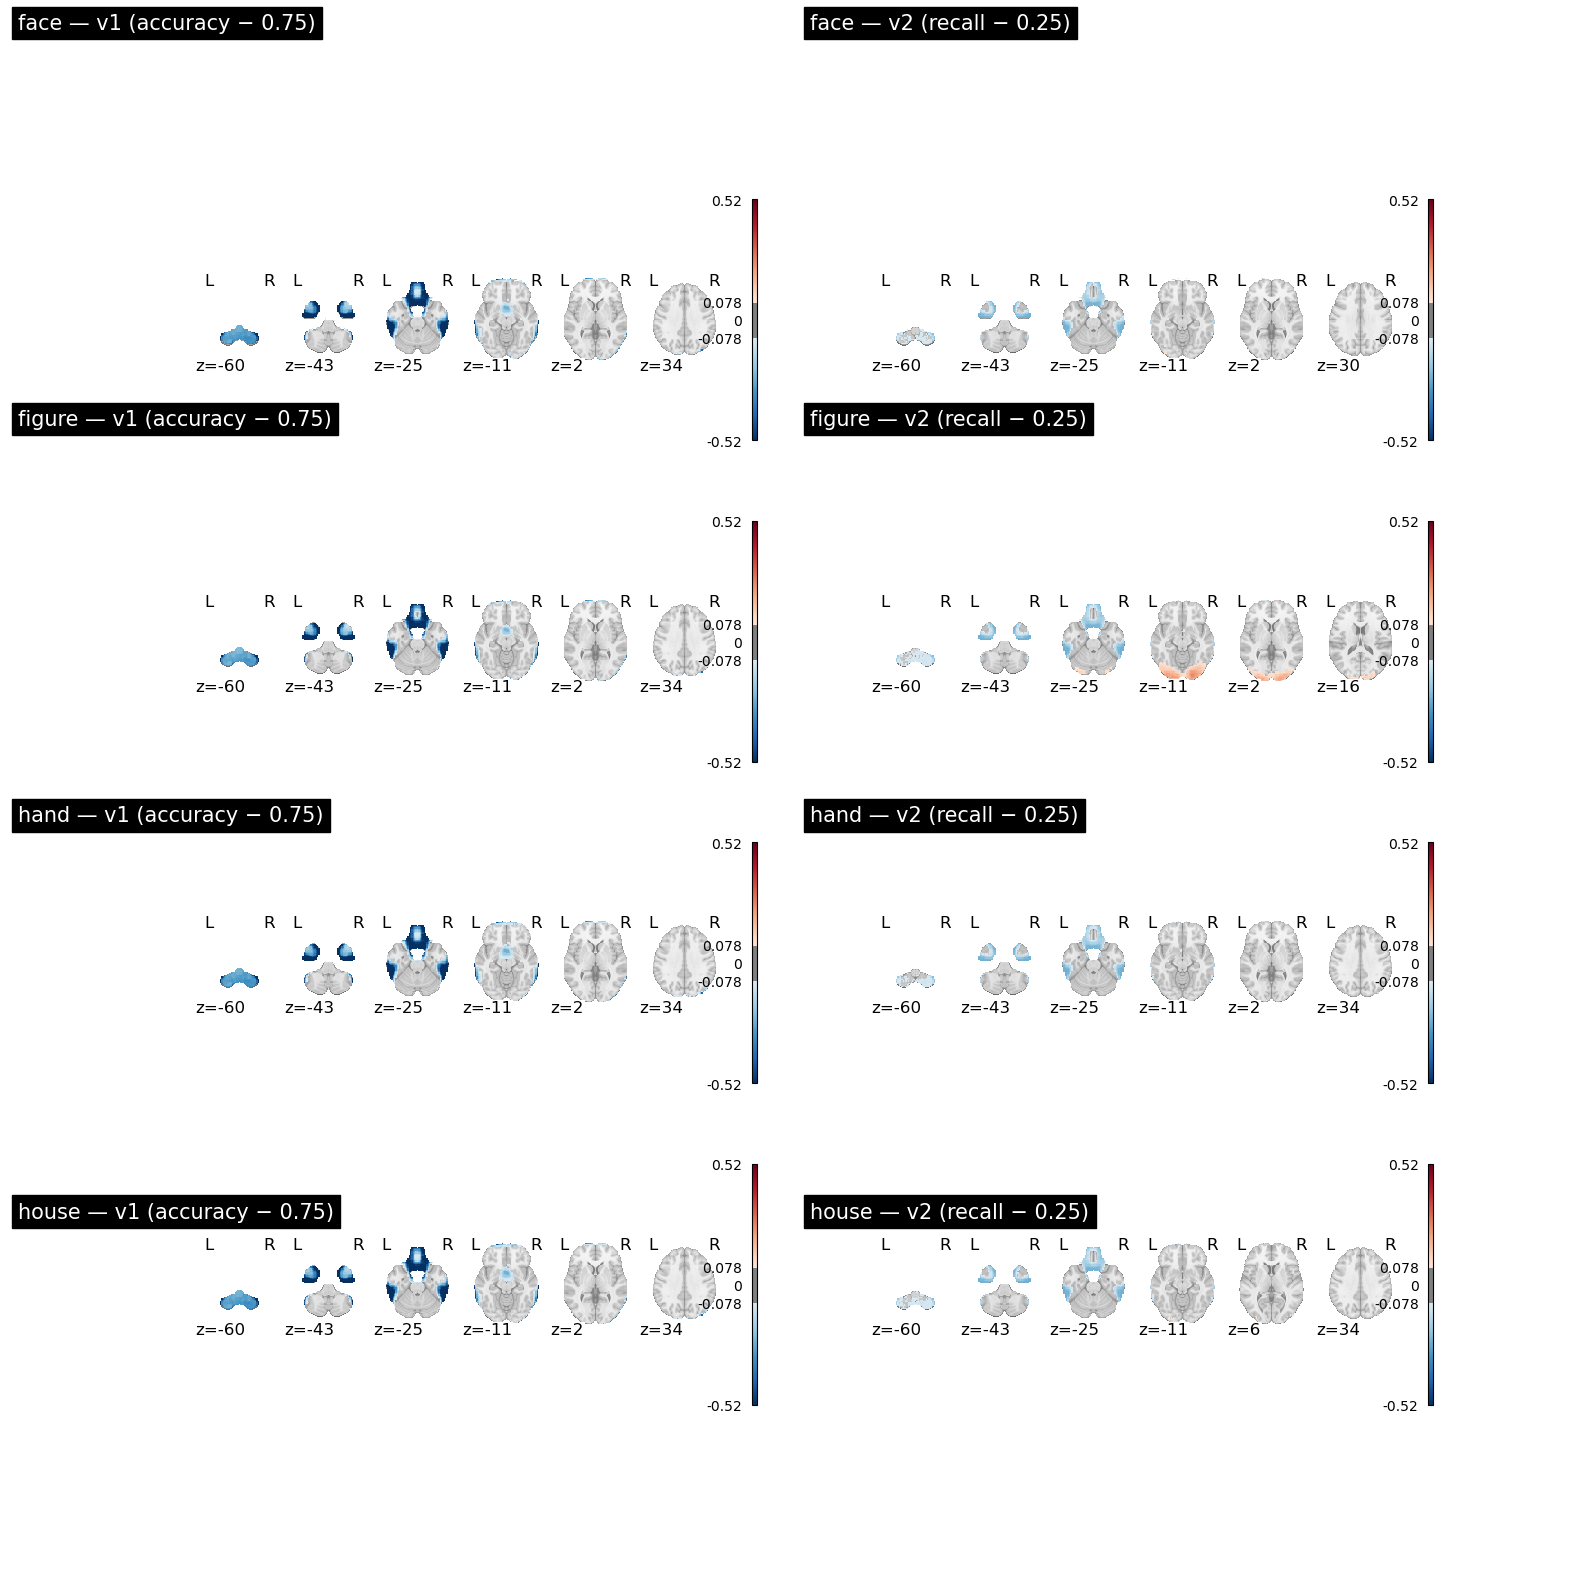

In [5]:
def chance_corrected(mean_img, chance):
    d = mean_img.get_fdata() - chance
    d[~mask_data] = 0.0
    return image.new_img_like(mean_img, d)

cc_v1 = {c: chance_corrected(mean_v1[c], CHANCE_V1) for c in STIM_CATS}
cc_v2 = {c: chance_corrected(mean_v2[c], CHANCE_V2) for c in STIM_CATS}

# Shared symmetric scale across BOTH versions and all categories
vmax = np.percentile(np.abs(np.concatenate(
    [cc_v1[c].get_fdata()[mask_data] for c in STIM_CATS] +
    [cc_v2[c].get_fdata()[mask_data] for c in STIM_CATS])), 99)
print(f'shared |Δ| cap (99th pct): {vmax:.3f}')

fig, axes = plt.subplots(len(STIM_CATS), 2, figsize=(16, 4 * len(STIM_CATS)))
for row, c in enumerate(STIM_CATS):
    plotting.plot_stat_map(cc_v1[c], threshold=vmax * 0.15, colorbar=True,
        title=f'{c} — v1 (accuracy − 0.75)', display_mode='z', cut_coords=6,
        axes=axes[row, 0], cmap='RdBu_r', symmetric_cbar=True, vmax=vmax)
    plotting.plot_stat_map(cc_v2[c], threshold=vmax * 0.15, colorbar=True,
        title=f'{c} — v2 (recall − 0.25)', display_mode='z', cut_coords=6,
        axes=axes[row, 1], cmap='RdBu_r', symmetric_cbar=True, vmax=vmax)
plt.tight_layout(); plt.show()

## 4. Per-category group inference (FDR t-maps), v1 vs v2

One-sample t-test at each voxel vs the version's chance (v1: 0.75, v2: 0.25), FDR-corrected.
t-maps are already chance-referenced, so v1 and v2 share a natural scale. The table reports
significant-voxel counts per category per version.

          v1_sig_voxels  v2_sig_voxels
category                              
face              59793           7134
figure            59541          17232
hand              59793           5781
house             59793           8230


/tmp/ipykernel_57911/330699471.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


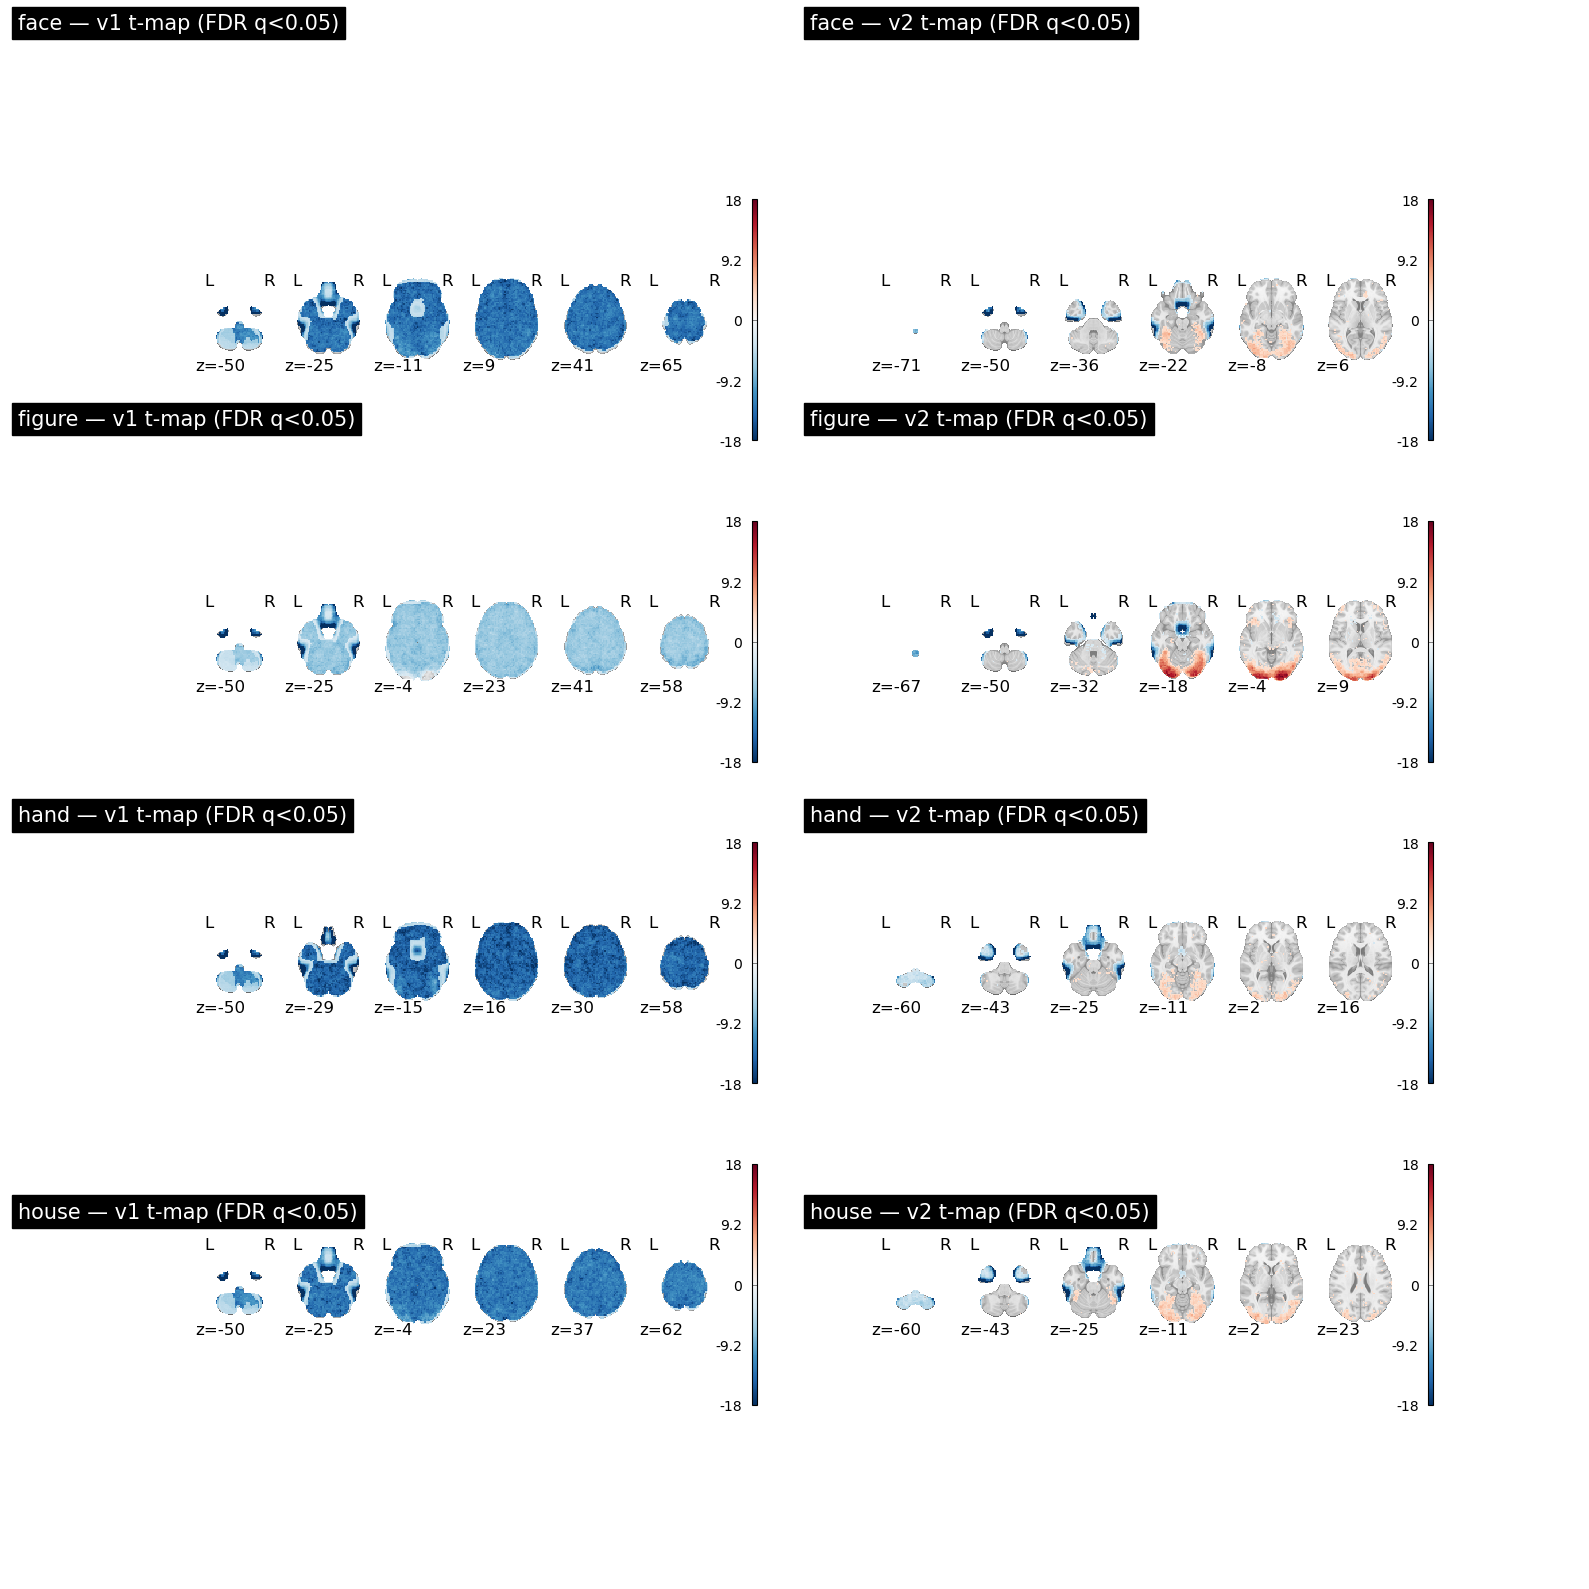

In [6]:
def fdr_tmap(img_4d, chance):
    data = img_4d.get_fdata()[mask_data, :].T          # (n_subjects, n_voxels)
    t, p = stats.ttest_1samp(data, popmean=chance, axis=0)
    t = np.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
    p = np.nan_to_num(p, nan=1.0, posinf=1.0, neginf=1.0)
    _, q = fdrcorrection(p, alpha=ALPHA_FDR)
    sig = np.zeros(mask_data.shape)
    sig[mask_data] = np.where(q < ALPHA_FDR, t, 0.0)
    return image.new_img_like(group_mask, sig), int((q < ALPHA_FDR).sum())

sig_v1, sig_v2, rows = {}, {}, []
for c in STIM_CATS:
    sig_v1[c], n1 = fdr_tmap(cat_v1[c], CHANCE_V1)
    sig_v2[c], n2 = fdr_tmap(cat_v2[c], CHANCE_V2)
    rows.append({'category': c, 'v1_sig_voxels': n1, 'v2_sig_voxels': n2})
sig_table = pd.DataFrame(rows).set_index('category')
print(sig_table)

tmax = np.percentile(np.abs(np.concatenate(
    [sig_v1[c].get_fdata()[mask_data] for c in STIM_CATS] +
    [sig_v2[c].get_fdata()[mask_data] for c in STIM_CATS])), 99) or 1.0

fig, axes = plt.subplots(len(STIM_CATS), 2, figsize=(16, 4 * len(STIM_CATS)))
for row, c in enumerate(STIM_CATS):
    plotting.plot_stat_map(sig_v1[c], threshold=0.1, colorbar=True,
        title=f'{c} — v1 t-map (FDR q<{ALPHA_FDR})', display_mode='z', cut_coords=6,
        axes=axes[row, 0], cmap='RdBu_r', symmetric_cbar=True, vmax=tmax)
    plotting.plot_stat_map(sig_v2[c], threshold=0.1, colorbar=True,
        title=f'{c} — v2 t-map (FDR q<{ALPHA_FDR})', display_mode='z', cut_coords=6,
        axes=axes[row, 1], cmap='RdBu_r', symmetric_cbar=True, vmax=tmax)
plt.tight_layout(); plt.show()

## 5. ROI summary, v1 vs v2 (chance-corrected)

Mean per-category value within visual cortex and fusiform ROIs, **chance-corrected** so a
single `y = 0` baseline serves both versions. Bars are group mean ± SEM of the per-subject
ROI means; stars are one-sample t-tests of the (chance-corrected) per-subject means vs 0.

Visual cortex: 7658 voxels
Fusiform: 320 voxels


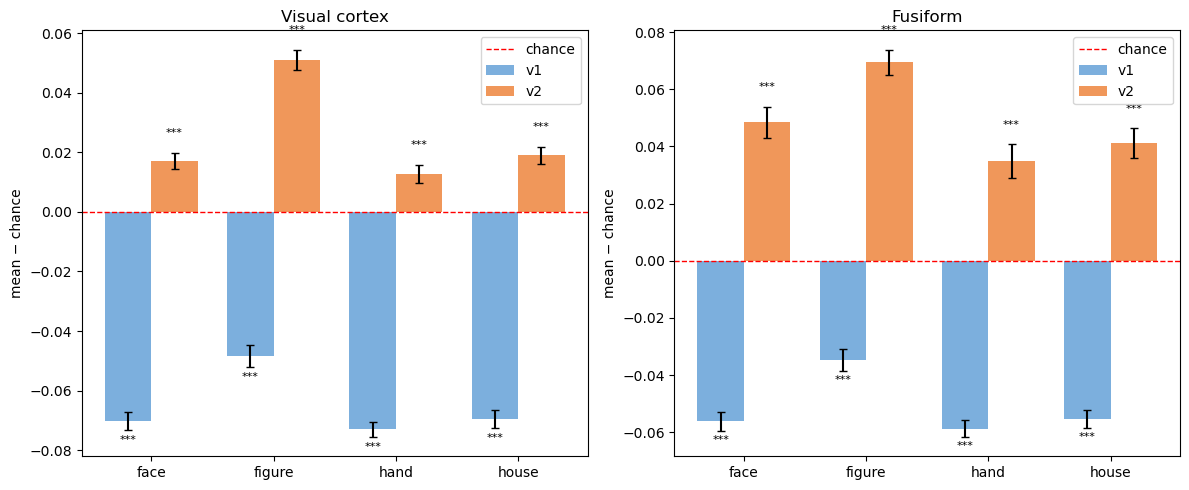

In [7]:
roi_masks = {}
for label, path in [('Visual cortex', VC_MASK_PATH), ('Fusiform', FUSIFORM_MASK_PATH)]:
    if Path(path).exists():
        roi_masks[label] = load_roi_mask(path, group_mask, mask_data)
        print(f'{label}: {roi_masks[label].sum()} voxels')
    else:
        print(f'{label}: mask not found at {path} — skipping')

def star(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'ns'

fig, axes = plt.subplots(1, len(roi_masks), figsize=(6 * len(roi_masks), 5), squeeze=False)
x = np.arange(len(STIM_CATS)); w = 0.38
for col, (label, rmask) in enumerate(roi_masks.items()):
    ax = axes[0, col]
    for off, (ver, cats, chance, color) in enumerate([
            ('v1', cat_v1, CHANCE_V1, '#5B9BD5'), ('v2', cat_v2, CHANCE_V2, '#ED7D31')]):
        means, sems = [], []
        for i, c in enumerate(STIM_CATS):
            vals = cats[c].get_fdata()[rmask, :].mean(axis=0) - chance   # per-subject, chance-corrected
            means.append(vals.mean()); sems.append(vals.std() / np.sqrt(len(vals)))
            _, p = stats.ttest_1samp(vals, 0.0)
            ax.text(i + (off - 0.5) * w, vals.mean() + np.sign(vals.mean() or 1) * (sems[-1] + 0.005),
                    star(p), ha='center', va='bottom', fontsize=8)
        ax.bar(x + (off - 0.5) * w, means, w, yerr=sems, capsize=3, alpha=0.8,
               color=color, label=ver)
    ax.axhline(0, color='red', ls='--', lw=1, label='chance')
    ax.set_xticks(x); ax.set_xticklabels(STIM_CATS)
    ax.set_title(label); ax.set_ylabel('mean − chance')
    ax.legend()
plt.tight_layout(); plt.show()

## 6. Findings summary

_(Fill in after running against the full cohort.)_

- **Overall map (Sec 1):** v1 vs v2 whole-brain accuracy on the identity line? → confirms
  `class_weight` is a near-no-op and the re-emitted v2 overall map is equivalent.
- **Per-category focality (Sec 2–4):** does v2 per-class recall localize each category more
  focally (e.g. face → fusiform/FFA, house → PPA/parahippocampal) than v1's majority-driven
  one-vs-rest accuracy? Compare FDR sig-voxel counts in the Sec 4 table.
- **ROI (Sec 5):** which categories are significantly above chance in visual cortex vs
  fusiform, and does the v1→v2 change alter that pattern?
- **Bottom line:** does Fix B change the substantive per-category conclusions, or mainly
  clean up the metric/chance interpretation?